In [5]:
import seaborn as sb
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.iolib.summary2 import summary_col

In [8]:
music = pd.read_excel(r"C:\Users\mahok\OneDrive - Boston University\Summer Project 2026\spotify dataset.xlsx")

In [9]:
music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113951 non-null  object 
 3   album_name        113988 non-null  object 
 4   track_name        113990 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [10]:
music['explicit'] = music['explicit'].astype(int)

In [11]:
music

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,0,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,0,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,CesÃ¡ria Evora,Best Of,Miss Perfumado,22,271466,0,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,0,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [12]:
#Popularity Summary Stats
Popularity = music['popularity'] 

mean = Popularity.mean()
median = Popularity.median()
iqr = Popularity.quantile(0.75) - Popularity.quantile(0.25)
max_val = Popularity.max()
min_val = Popularity.min()
std = Popularity.std()

print("Mean:", mean)
print("Median:", median)
print("IQR:", iqr)
print("Max:", max_val)
print("Min:", min_val)
print("Standard Deviation:", std)

Mean: 33.2385350877193
Median: 35.0
IQR: 33.0
Max: 100
Min: 0
Standard Deviation: 22.305078493368146


In [13]:
music.corr(numeric_only = True)['popularity']
#Highest strength: instrumentalness > loudness > speechiness > explicit > valence > danceability
#Lowest strength: energy < key < liveness < duration_ms < tempo < mode < acousticness < time_signature

Unnamed: 0          0.032142
popularity          1.000000
duration_ms        -0.007101
explicit            0.044082
danceability        0.035448
energy              0.001056
key                -0.003853
loudness            0.050423
mode               -0.013931
speechiness        -0.044927
acousticness       -0.025472
instrumentalness   -0.095139
liveness           -0.005387
valence            -0.040534
tempo               0.013205
time_signature      0.031073
Name: popularity, dtype: float64

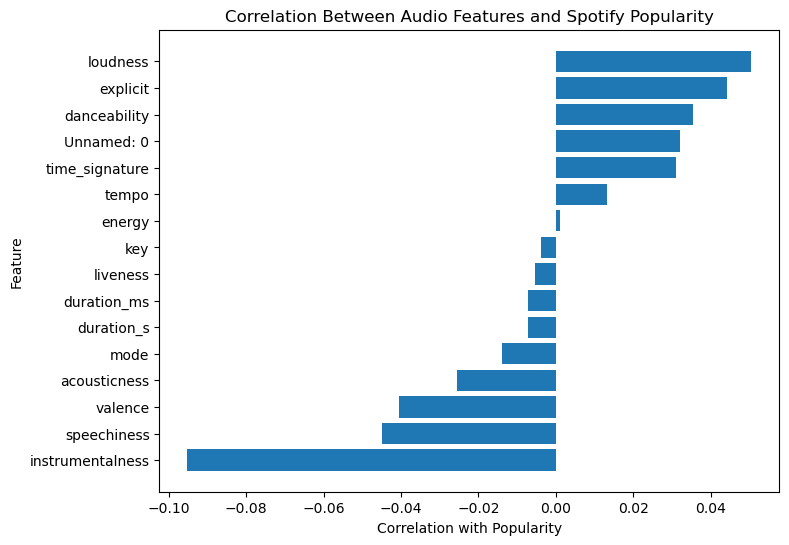

In [67]:
#Correlation Bar Chart
popularity_corr = music.corr(numeric_only=True)['popularity']
popularity_corr = popularity_corr.drop(['popularity', 'popularity_group']).sort_values()

plt.figure(figsize=(8,6))
plt.barh(popularity_corr.index, popularity_corr.values)

plt.xlabel("Correlation with Popularity")
plt.ylabel("Feature")
plt.title("Correlation Between Audio Features and Spotify Popularity")

plt.savefig("popularity_correlation.png", dpi=300, bbox_inches="tight")

plt.show()

In [14]:
smf.ols('popularity ~ instrumentalness', data = music).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             popularity   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1041.
Date:                Tue, 04 Aug 2026   Prob (F-statistic):          2.05e-227
Time:                        21:53:20   Log-Likelihood:            -5.1519e+05
No. Observations:              114000   AIC:                         1.030e+06
Df Residuals:                  113998   BIC:                         1.030e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           34.3083      0.074    465.853      0.000      34.164      34.453
instrumentalness    -6.8553      0.212    -32.269      0.000      -7.272      -6.439
==============================================================================
Omnibus:                    16277.790   Durbin-Watson:                   0.540
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3915.016
Skew:                           0.014   Prob(JB):                         0.00
Kurtosis:                       2.093   Cond. No.                         3.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
#Backwards Selection: Everything but key
smf.ols('popularity ~ instrumentalness + loudness + speechiness + explicit + valence + danceability + time_signature + acousticness + mode + tempo + duration_ms + liveness + key + energy', data = music).fit().summary
smf.ols('popularity ~ instrumentalness + loudness + speechiness + explicit + valence + danceability + time_signature + acousticness + mode + tempo + duration_ms + liveness + energy', data = music).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             popularity   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     224.0
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        21:53:21   Log-Likelihood:            -5.1427e+05
No. Observations:              114000   AIC:                         1.029e+06
Df Residuals:                  113986   BIC:                         1.029e+06
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           32.9658      0.876     37.626      0.000      31.249      34.683
instrumentalness    -7.9920      0.255    -31.300      0.000      -8.492      -7.492
loudness             0.1063      0.024      4.522      0.000       0.060       0.152
speechiness        -15.3081      0.684    -22.373      0.000     -16.649     -13.967
explicit             3.5198      0.249     14.122      0.000       3.031       4.008
valence             -9.3310      0.317    -29.458      0.000      -9.952      -8.710
danceability         8.0095      0.468     17.125      0.000       7.093       8.926
time_signature       1.0284      0.157      6.561      0.000       0.721       1.336
acousticness        -0.7942      0.306     -2.600      0.009      -1.393      -0.195
mode                -0.6922      0.137     -5.042      0.000      -0.961      -0.423
tempo                0.0148      0.002      6.525      0.000       0.010       0.019
duration_ms      -1.648e-06   6.25e-07     -2.636      0.008   -2.87e-06   -4.23e-07
liveness             1.6527      0.366      4.511      0.000       0.935       2.371
energy              -2.8624      0.536     -5.342      0.000      -3.913      -1.812
==============================================================================
Omnibus:                    12409.271   Durbin-Watson:                   0.572
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3454.544
Skew:                          -0.023   Prob(JB):                         0.00
Kurtosis:                       2.148   Cond. No.                     3.75e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.75e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [16]:
#Forwards Selection: All variables are in
xVars = []
for i in xVars:
    formula = 'popularity ~ instrumentalness + valence + danceability + speechiness + explicit + tempo + time_signature + mode + liveness + duration_ms + energy + loudness + acousticness + key + liveness + ' + i
    reg = smf.ols(formula, data = music).fit()
    print (i, reg.rsquared_adj)


In [17]:
fs = smf.ols('popularity ~ instrumentalness+ valence + danceability + speechiness + explicit  + tempo + time_signature + mode + liveness + duration_ms + energy + loudness + acousticness + key + liveness', data = music).fit()
fs.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             popularity   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     208.2
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        21:53:21   Log-Likelihood:            -5.1427e+05
No. Observations:              114000   AIC:                         1.029e+06
Df Residuals:                  113985   BIC:                         1.029e+06
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           33.1117      0.882     37.549      0.000      31.383      34.840
instrumentalness    -7.9911      0.255    -31.297      0.000      -8.492      -7.491
valence             -9.3212      0.317    -29.421      0.000      -9.942      -8.700
danceability         8.0147      0.468     17.136      0.000       7.098       8.931
speechiness        -15.2962      0.684    -22.354      0.000     -16.637     -13.955
explicit             3.5171      0.249     14.111      0.000       3.029       4.006
tempo                0.0148      0.002      6.527      0.000       0.010       0.019
time_signature       1.0285      0.157      6.562      0.000       0.721       1.336
mode                -0.7188      0.139     -5.189      0.000      -0.990      -0.447
liveness             1.6498      0.366      4.503      0.000       0.932       2.368
duration_ms      -1.643e-06   6.25e-07     -2.626      0.009   -2.87e-06   -4.17e-07
energy              -2.8542      0.536     -5.326      0.000      -3.904      -1.804
loudness             0.1064      0.024      4.526      0.000       0.060       0.153
acousticness        -0.7956      0.306     -2.604      0.009      -1.394      -0.197
key                 -0.0270      0.019     -1.458      0.145      -0.063       0.009
==============================================================================
Omnibus:                    12406.737   Durbin-Watson:                   0.572
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3454.136
Skew:                          -0.023   Prob(JB):                         0.00
Kurtosis:                       2.148   Cond. No.                     3.77e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.77e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

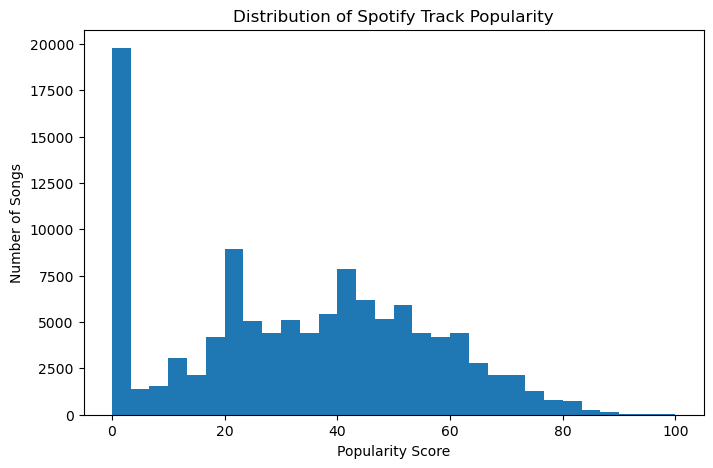

In [59]:
#Popularity Distribution 
plt.figure(figsize=(8,5))

plt.hist(music["popularity"], bins=30)

plt.xlabel('Popularity Score')
plt.ylabel('Number of Songs')
plt.title('Distribution of Spotify Track Popularity')

plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
music[music.popularity >= 80].sort_values(by = 'popularity', ascending = False).head(20)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
81051,81051,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,0,0.714,0.472,...,-7.375,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,pop
20001,20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,0,0.714,0.472,...,-7.375,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,dance
51664,51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,0,0.621,0.782,...,-5.548,1,0.0440,0.01250,0.033000,0.2300,0.550,128.033,4,hip-hop
81210,81210,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,1,0.561,0.965,...,-3.673,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,pop
20008,20008,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,1,0.561,0.965,...,-3.673,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,dance
30003,30003,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,1,0.561,0.965,...,-3.673,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,edm
68303,68303,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,0,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,latino
89411,89411,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,0,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,reggaeton
88410,88410,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,0,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,reggae
67356,67356,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,0,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,latin


In [20]:
music.groupby('track_genre')['popularity'].mean().sort_values(ascending = False).head(10)

track_genre
pop-film     59.283
k-pop        56.896
chill        53.651
sad          52.379
grunge       49.594
indian       49.539
anime        48.772
emo          48.128
sertanejo    47.866
pop          47.576
Name: popularity, dtype: float64

In [21]:
music.groupby('explicit')['popularity'].mean().sort_values(ascending = False).head(10)

explicit
1    36.454191
0    32.937891
Name: popularity, dtype: float64

In [22]:
music.groupby('mode')['popularity'].mean().sort_values(ascending = False).head(10)

mode
0    33.650645
1    33.004251
Name: popularity, dtype: float64

In [23]:
smf.ols('popularity ~ explicit', data = music).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             popularity   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     222.0
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           3.78e-50
Time:                        21:53:21   Log-Likelihood:            -5.1560e+05
No. Observations:              114000   AIC:                         1.031e+06
Df Residuals:                  113998   BIC:                         1.031e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     32.9379      0.069    477.262      0.000      32.803      33.073
explicit       3.5163      0.236     14.898      0.000       3.054       3.979
==============================================================================
Omnibus:                    18565.109   Durbin-Watson:                   0.534
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4167.507
Skew:                           0.039   Prob(JB):                         0.00
Kurtosis:                       2.066   Cond. No.                         3.60
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [24]:
music['duration_s'] = music['duration_ms']/1000

In [25]:
music

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_s
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,...,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,230.666
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,...,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,149.610
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,...,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,210.826
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,...,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,201.933
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,...,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,198.853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,0,0.172,0.2350,...,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,384.999
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,0,0.174,0.1170,...,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,385.000
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,CesÃ¡ria Evora,Best Of,Miss Perfumado,22,271466,0,0.629,0.3290,...,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,271.466
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,0,0.587,0.5060,...,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,283.893


<function matplotlib.pyplot.show(close=None, block=None)>

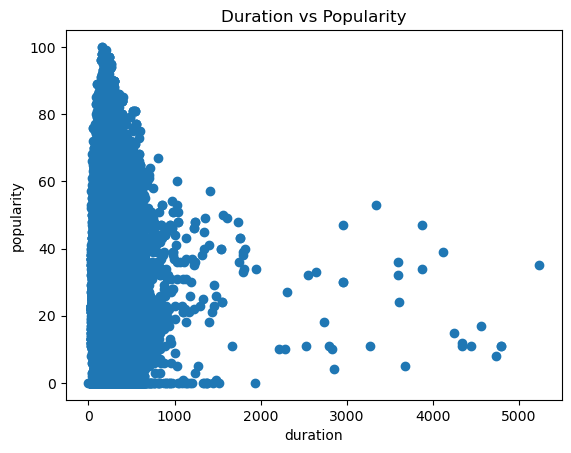

In [26]:
plt.scatter(x = 'duration_s', y = 'popularity', data = music)
plt.xlabel('duration')
plt.ylabel('popularity')
plt.title('Duration vs Popularity')
plt.show

In [27]:
music.duration_s.mean()

np.float64(228.02915311403507)

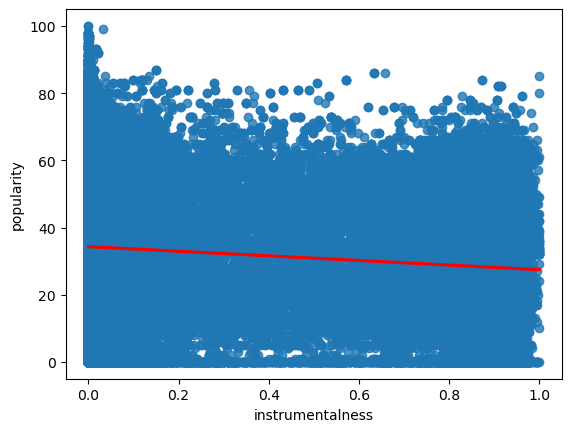

In [54]:
#Relationship Between Instrumentalness and Song Popularity
sb.regplot(x = 'instrumentalness', y = 'popularity', data = music, line_kws = {'color': 'red'})
plt.show()

In [29]:
smf.ols('popularity ~ instrumentalness+ valence + danceability + speechiness + explicit  + tempo + time_signature + mode + liveness + duration_ms + energy + loudness + acousticness + key + liveness', data = music).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             popularity   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     208.2
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        21:53:29   Log-Likelihood:            -5.1427e+05
No. Observations:              114000   AIC:                         1.029e+06
Df Residuals:                  113985   BIC:                         1.029e+06
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           33.1117      0.882     37.549      0.000      31.383      34.840
instrumentalness    -7.9911      0.255    -31.297      0.000      -8.492      -7.491
valence             -9.3212      0.317    -29.421      0.000      -9.942      -8.700
danceability         8.0147      0.468     17.136      0.000       7.098       8.931
speechiness        -15.2962      0.684    -22.354      0.000     -16.637     -13.955
explicit             3.5171      0.249     14.111      0.000       3.029       4.006
tempo                0.0148      0.002      6.527      0.000       0.010       0.019
time_signature       1.0285      0.157      6.562      0.000       0.721       1.336
mode                -0.7188      0.139     -5.189      0.000      -0.990      -0.447
liveness             1.6498      0.366      4.503      0.000       0.932       2.368
duration_ms      -1.643e-06   6.25e-07     -2.626      0.009   -2.87e-06   -4.17e-07
energy              -2.8542      0.536     -5.326      0.000      -3.904      -1.804
loudness             0.1064      0.024      4.526      0.000       0.060       0.153
acousticness        -0.7956      0.306     -2.604      0.009      -1.394      -0.197
key                 -0.0270      0.019     -1.458      0.145      -0.063       0.009
==============================================================================
Omnibus:                    12406.737   Durbin-Watson:                   0.572
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3454.136
Skew:                          -0.023   Prob(JB):                         0.00
Kurtosis:                       2.148   Cond. No.                     3.77e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.77e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [30]:
#Shows a pattern = instrumentalness, valence, explicit, tempo, liveness, duration, energy, acousticness]
features = ['instrumentalness', 'valence', 'danceability', 'speechiness', 'explicit', 'tempo', 'time_signature', 'mode', 'liveness', 'duration_s', 'energy', 'loudness', 'acousticness', 'key']
music['popularity_group'] = (music['popularity'] >= 33.24).astype(int)
result = music.groupby('popularity_group')[features].mean()
result

,instrumentalness,valence,danceability,speechiness,explicit,tempo,time_signature,mode,liveness,duration_s,energy,loudness,acousticness,key
popularity_group,,,,,,,,,,,,,,
0,0.189003,0.483409,0.556979,0.094408,0.081033,121.770553,3.889677,0.643266,0.213811,227.931067,0.646108,-8.505287,0.319316,5.303282
1,0.124696,0.465181,0.576144,0.075370,0.089750,122.506806,3.917697,0.632117,0.213307,228.122477,0.636887,-8.024592,0.310718,5.314715


In [31]:
music.groupby('track_genre')['popularity'].mean().sort_values(ascending = False).head(5)

track_genre
pop-film    59.283
k-pop       56.896
chill       53.651
sad         52.379
grunge      49.594
Name: popularity, dtype: float64

In [32]:
features1 = ['popularity','instrumentalness', 'valence', 'danceability', 'speechiness', 'explicit', 'tempo', 'time_signature', 'mode', 'liveness', 'duration_s', 'energy', 'loudness', 'acousticness', 'key']
popular_genre = music[(music.track_genre == 'pop-film')|(music.track_genre == 'k-pop')|(music.track_genre == 'chill')|(music.track_genre == 'sad')|(music.track_genre == 'grunge')]
popular_genre.groupby('track_genre')[features1].mean().sort_values(by = 'popularity', ascending = False)


,popularity,instrumentalness,valence,danceability,speechiness,explicit,tempo,time_signature,mode,liveness,duration_s,energy,loudness,acousticness,key
track_genre,,,,,,,,,,,,,,,
pop-film,59.283,0.008124,0.529253,0.597146,0.064057,0.001,117.257478,3.899,0.557,0.166397,279.657084,0.604562,-7.871622,0.440696,5.296
k-pop,56.896,0.009828,0.556915,0.647732,0.088025,0.049,119.243969,3.916,0.519,0.176296,251.277169,0.675654,-6.470775,0.292968,5.328
chill,53.651,0.178022,0.403770,0.664346,0.102167,0.171,115.479376,3.944,0.613,0.168200,169.009967,0.426723,-10.460978,0.534097,5.355
sad,52.379,0.105740,0.422050,0.692378,0.130431,0.450,119.064950,3.970,0.609,0.171611,153.800880,0.462470,-10.275018,0.473710,5.365
grunge,49.594,0.036983,0.400373,0.457062,0.061054,0.072,129.349208,3.915,0.659,0.222126,235.579061,0.803290,-5.660960,0.053441,5.255


In [33]:
popular_genre.corr(numeric_only = True).sort_values(by = 'popularity', ascending = False)['popularity']

popularity          1.000000
popularity_group    0.790628
valence             0.080809
danceability        0.076601
Unnamed: 0          0.070328
time_signature      0.046629
loudness            0.028481
speechiness         0.014063
duration_s          0.008587
duration_ms         0.008587
energy              0.004214
tempo               0.002310
key                 0.000645
acousticness       -0.000118
instrumentalness   -0.029920
liveness           -0.057513
mode               -0.061297
explicit           -0.069475
Name: popularity, dtype: float64

In [34]:
smf.ols('popularity ~ valence', data = popular_genre).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             popularity   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     32.85
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           1.05e-08
Time:                        21:53:29   Log-Likelihood:                -20666.
No. Observations:                5000   AIC:                         4.134e+04
Df Residuals:                    4998   BIC:                         4.135e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     51.7498      0.503    102.871      0.000      50.764      52.736
valence        5.6454      0.985      5.732      0.000       3.714       7.576
==============================================================================
Omnibus:                     1736.342   Durbin-Watson:                   1.073
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5944.550
Skew:                          -1.755   Prob(JB):                         0.00
Kurtosis:                       7.026   Cond. No.                         5.64
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [35]:
#Forwards Selection: 
xVars = ['duration_s', 'acousticness', 'key', 'liveness']
for i in xVars:
    formula = 'popularity ~ valence + explicit + danceability + mode + liveness + time_signature + instrumentalness + speechiness + loudness + energy + tempo +' + i
    reg = smf.ols(formula, data = popular_genre).fit()
    print (i, reg.rsquared_adj)


duration_s 0.024574371202447542
acousticness 0.024566042472752292
key 0.0245708100664348
liveness 0.024761596348053083


In [36]:
music.isnull().sum()

Unnamed: 0           0
track_id             0
artists             49
album_name          12
track_name          10
popularity           0
duration_ms          0
explicit             0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
time_signature       0
track_genre          0
duration_s           0
popularity_group     0
dtype: int64

In [37]:
#Method 1 Predictive Model 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

train = music.drop(['popularity', 'Unnamed: 0', 'artists','track_id', 'album_name', 'track_name', 'track_genre', 'duration_ms', 'popularity_group'], axis = 1)
test = music['popularity']

X_train, X_test, y_train, y_test = train_test_split(train, test, test_size = 0.3, random_state = 42)

reg = LinearRegression()
reg.fit(X_train, y_train)
pred = reg.predict(X_test)
reg.score(X_test, y_test)


0.023891364748261812

In [38]:
#Method 1 Predictive Model (Classification)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

train = music.drop(['popularity', 'Unnamed: 0', 'artists','track_id', 'album_name', 'track_name', 'track_genre', 'duration_ms', 'popularity_group'], axis = 1)
test = music['popularity_group']

X_train, X_test, y_train, y_test = train_test_split(train, test, test_size = 0.3, random_state = 42)

reg = LinearRegression()
reg.fit(X_train, y_train)
pred = reg.predict(X_test)
reg.score(X_test, y_test)


0.03619402361549151

In [39]:
#Method 2 Predictive Model
test = music['popularity']
y_reg_train_pred = reg.predict(X_train)
y_reg_test_pred = reg.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
reg_train_mse = mean_squared_error(y_train, y_reg_train_pred)
reg_train_r2 = r2_score(y_train, y_reg_train_pred)

reg_test_mse = mean_squared_error(y_test, y_reg_test_pred)
reg_test_r2 = r2_score(y_test, y_reg_test_pred)

reg_train_mse
reg_train_r2
reg_test_mse
reg_test_r2

pd.DataFrame(['Linear regression', reg_train_mse, reg_train_r2, reg_test_mse, reg_test_r2]).transpose()


,0,1,2,3,4
0,Linear regression,0.240549,0.037159,0.240829,0.036194


In [40]:
#Method 2 Predictive Model (Classification)
test = music['popularity_group']
y_reg_train_pred = reg.predict(X_train)
y_reg_test_pred = reg.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
reg_train_mse = mean_squared_error(y_train, y_reg_train_pred)
reg_train_r2 = r2_score(y_train, y_reg_train_pred)

reg_test_mse = mean_squared_error(y_test, y_reg_test_pred)
reg_test_r2 = r2_score(y_test, y_reg_test_pred)

reg_train_mse
reg_train_r2
reg_test_mse
reg_test_r2

pd.DataFrame(['Linear regression', reg_train_mse, reg_train_r2, reg_test_mse, reg_test_r2]).transpose()

,0,1,2,3,4
0,Linear regression,0.240549,0.037159,0.240829,0.036194


In [44]:
#Random Forest Classification Model
train = music.drop(['popularity', 'Unnamed: 0', 'artists','track_id', 'album_name', 'track_name', 'track_genre', 'duration_ms', 'popularity_group'], axis = 1)
test = music['popularity_group']

X_train, X_test, y_train, y_test = train_test_split(train, test, test_size = 0.3, random_state = 42)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier (n_estimators = 100, random_state = 42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7752631578947369


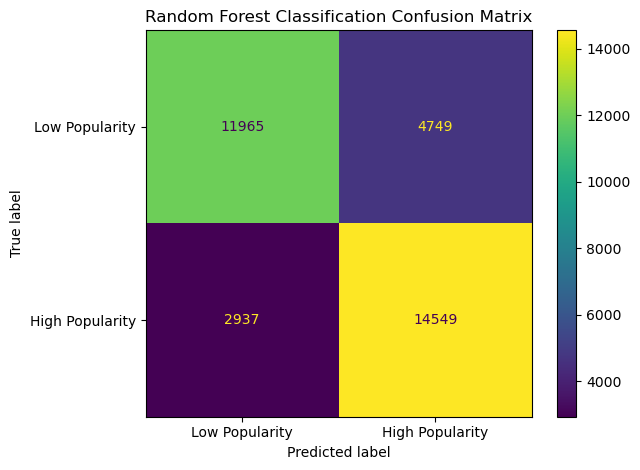

In [49]:
#Random Forest Classification Performance Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low Popularity", "High Popularity"])
disp.plot()

plt.title("Random Forest Classification Confusion Matrix")
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

importance = pd.DataFrame({'Feature':train.columns, 'Importance': rf.feature_importances_})
importance.sort_values(by = 'Importance', ascending = False).head(10)

,Feature,Importance
7,acousticness,0.102819
13,duration_s,0.097381
1,danceability,0.096483
6,speechiness,0.095564
10,valence,0.095201
11,tempo,0.093852
2,energy,0.091921
4,loudness,0.091042
9,liveness,0.088228
8,instrumentalness,0.073613


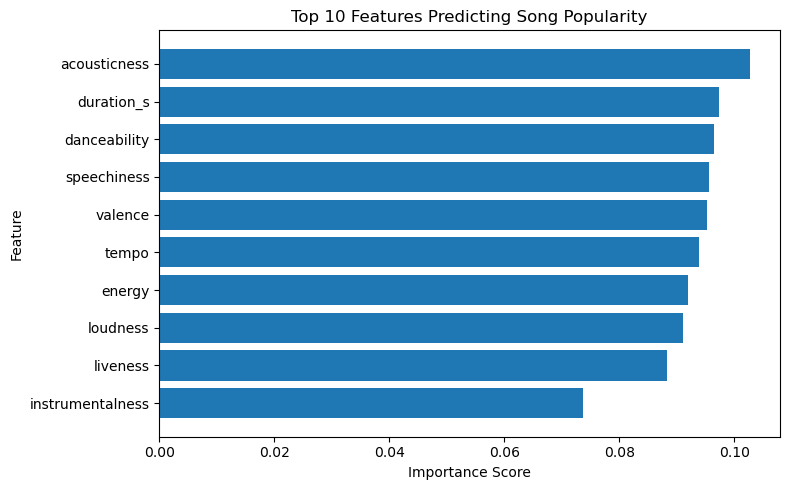

In [47]:
#Bar chart of the Feature Importance
top_features = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

# Create bar chart
plt.figure(figsize=(8, 5))
plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Features Predicting Song Popularity")

# Put most important feature at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("top10_features.png", dpi=300, bbox_inches="tight")
plt.show()